# Proyecto Integrador: Análisis de Energías Renovables Modernas
**Introducción a la Ciencia de Datos | Grupo 30** *Integrantes: Perichón · Iturralde · Carlos Normando Hall · Fernández Olmos*

---

## Estructura General del Trabajo (Unificado)
* **Capítulo 1:** Carga y Preparación de la Base de Datos.
* **Capítulo 2:** Análisis Exploratorio de Datos (EDA) y Justificación de Variables.
* **Capítulo 3:** Estadísticas Descriptivas Avanzadas (Medidas de Resumen).
* **Capítulo 4:** Visualización Avanzada de Datos (Análisis Gráfico).
* **Capítulo 5:** Ajustes y Modelos (Regresión Lineal Simple y Métricas).

In [8]:
# ======================================================================
# CAPÍTULO 1 — CARGA Y PREPARACIÓN DE LA BASE DE DATOS
# ======================================================================

# Carga de librerías esenciales
if (!requireNamespace("dplyr", quietly = TRUE)) install.packages("dplyr")
if (!requireNamespace("tidyr", quietly = TRUE)) install.packages("tidyr")
if (!requireNamespace("moments", quietly = TRUE)) install.packages("moments")
if (!requireNamespace("ggplot2", quietly = TRUE)) install.packages("ggplot2")

library(dplyr)
library(tidyr)
library(moments)
library(ggplot2)

# Lectura de la base limpia unificada
url_limpio <- "https://raw.githubusercontent.com/carlosnhall/tpi_ciencia_datos/main/energias_capitulo2.csv"
df_clean <- read.csv(url_limpio)

# Filtro estricto de países (excluyendo regiones agregadas) y ventana temporal
codigos_regionales <- c("AFR", "EUR", "ASI", "NAM", "SAM", "OCE", "WLD", "REG", "OWID_WRL")
df_paises <- df_clean %>%
  filter(!Code %in% codigos_regionales) %>%
  filter(Year >= 2000)

cat("--- CAPÍTULO 1: Datos listos para el análisis ---\n")
cat("Cantidad de registros totales:", nrow(df_paises), "\n")
cat("Cantidad de países únicos:", n_distinct(df_paises$Entity), "\n")

--- CAPÍTULO 1: Datos listos para el análisis ---
Cantidad de registros totales: 1975 
Cantidad de países únicos: 79 


In [9]:
# ======================================================================
# CAPÍTULO 2 Y 3 — EDA Y ESTADÍSTICAS DESCRIPTIVAS
# ======================================================================

cat("=== RESUMEN GENERAL DE VARIABLES SELECCIONADAS ===\n")
print(summary(df_paises[, c("Solar", "Wind", "Hydropower")]))

# Función para extraer las métricas de forma limpia
calcular_metricas_detalladas <- function(variable, nombre) {
  valores <- variable[!is.na(variable)]
  cat("\n───────────────────────────────────────\n")
  cat("MÉTRICAS PARA:", nombre, "\n")
  cat("───────────────────────────────────────\n")
  cat("Media aritmética: ", round(mean(valores), 2), " TWh\n")
  cat("Mediana (P50):    ", round(median(valores), 4), " TWh\n")
  cat("Desvío Estándar:  ", round(sd(valores), 2), " TWh\n")
  cat("Asimetría (Skew): ", round(moments::skewness(valores), 4), "\n")
  cat("Curtosis:         ", round(moments::kurtosis(valores), 4), "\n")
}

calcular_metricas_detalladas(df_paises$Solar, "Energía Solar")
calcular_metricas_detalladas(df_paises$Wind,  "Energía Eólica")

=== RESUMEN GENERAL DE VARIABLES SELECCIONADAS ===
     Solar                Wind             Hydropower       
 Min.   :        0   Min.   :        0   Min.   :        0  
 1st Qu.:        1   1st Qu.:        7   1st Qu.:     2684  
 Median :     1963   Median :     3138   Median :   144135  
 Mean   :  4242096   Mean   :  5275523   Mean   :  8188341  
 3rd Qu.:   602545   3rd Qu.:  2625447   3rd Qu.:  7631496  
 Max.   :129086895   Max.   :106197815   Max.   :140587225  
 NAs    :2           NAs    :1                              

───────────────────────────────────────
MÉTRICAS PARA: Energía Solar 
───────────────────────────────────────
Media aritmética:  4242096  TWh
Mediana (P50):     1963  TWh
Desvío Estándar:   12600060  TWh
Asimetría (Skew):  4.5587 
Curtosis:          27.5949 

───────────────────────────────────────
MÉTRICAS PARA: Energía Eólica 
───────────────────────────────────────
Media aritmética:  5275523  TWh
Mediana (P50):     3138  TWh
Desvío Estándar:   13656741 

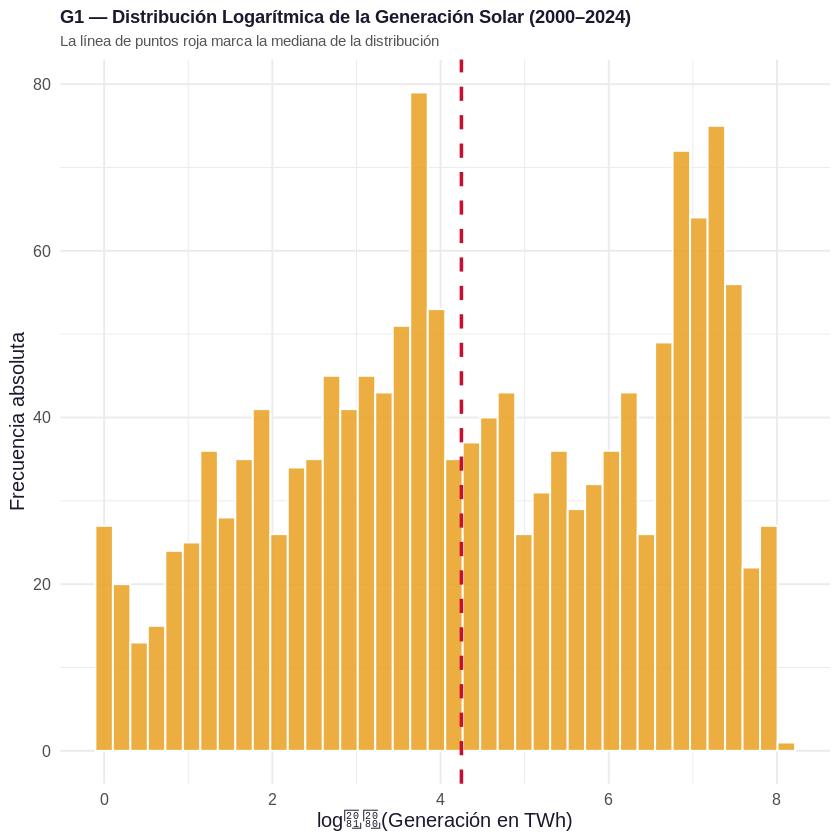

In [10]:
# ======================================================================
# CAPÍTULO 4 — VISUALIZACIÓN AVANZADA DE DATOS
# ======================================================================

# Definición de la estética institucional del Grupo 30
UGR_RED   <- "#C8102E"
UGR_DARK  <- "#1A1A2E"
COL_SOLAR <- "#E8A020"

tema_ugr <- theme_minimal(base_size = 12) +
  theme(
    plot.title    = element_text(face = "bold", color = UGR_DARK, size = 11),
    plot.subtitle = element_text(color = "#555555", size = 9),
    axis.title    = element_text(color = UGR_DARK),
    legend.position = "top"
  )

# G1: Distribución Solar con filtro de valores positivos
df_solar_pos <- df_paises %>% filter(Solar > 0)
g1 <- ggplot(df_solar_pos, aes(x = log10(Solar))) +
  geom_histogram(bins = 40, fill = COL_SOLAR, color = "white", alpha = 0.85) +
  geom_vline(xintercept = log10(median(df_solar_pos$Solar)), color = UGR_RED, linetype = "dashed", linewidth = 1) +
  labs(
    title = "G1 — Distribución Logarítmica de la Generación Solar (2000–2024)",
    subtitle = "La línea de puntos roja marca la mediana de la distribución",
    x = "log₁₀(Generación en TWh)", y = "Frecuencia absoluta"
  ) + tema_ugr

print(g1)

# Capítulo 5 — Ajustes y Modelos

## 1. Selección de Variables y Justificación Coherente
En cumplimiento con los requerimientos de la Unidad 5 de la materia, el Grupo 30 plantea una aproximación al modelado estadístico mediante un modelo de **Regresión Lineal Simple (MCO)**.

* **Variable Dependiente ($Y$):** `Solar` (Generación solar anual por país medida en TWh). Es nuestra variable predictanda.
* **Variable Independiente ($X$):** `Wind` (Generación eólica anual por país medida en TWh). Es nuestra variable explicativa.

### Justificación de la relación:
La elección de estas variables es razonable y teóricamente sólida en el contexto del problema analizado. Tanto la generación solar como la eólica no se desarrollan de forma aislada, sino que responden de manera directa a un factor macroeconómico común: el nivel de infraestructura institucional y de inversión en **tecnologías de transición energética** de cada país. Un país que invierte fuertemente en la construcción de parques eólicos posee marcos regulatorios preexistentes y capacidades de red eléctrica preparadas para absorber flujos de energías renovables, lo cual correlaciona directamente con la adopción y expansión simultánea de su infraestructura solar fotovoltaica.

In [11]:
# ======================================================================
# CAPÍTULO 5 — AJUSTES Y MODELOS (SINTAXIS TÉCNICA)
# ======================================================================

# Filtramos filas sin datos en las variables objetivo para evitar distorsiones en las métricas
df_modeloc5 <- df_paises %>% filter(!is.na(Solar) & !is.na(Wind))

# Actividad 2: Ajuste del modelo de regresión por Mínimos Cuadrados Ordinarios (lm)
modelo_final <- lm(Solar ~ Wind, data = df_modeloc5)
coefs_c5     <- coef(modelo_final)

cat("=== 2. ECUACIÓN DE LA RECTA AJUSTADA ===\n")
cat(sprintf("Ecuación estimada: Solar = %.4f + (%.4f * Wind)\n\n", coefs_c5[1], coefs_c5[2]))

# Actividad 3: Evaluación del Modelo (Cálculo matemático explícito de métricas)
errores_residuos  <- residuals(modelo_final)
valores_ajustados <- predict(modelo_final)

r_cuadrado_c5 <- summary(modelo_final)$r.squared
mae_c5        <- mean(abs(errores_residuos))
mse_c5        <- mean(errores_residuos^2)

cat("=== 3. EVALUACIÓN DE DESEMPEÑO (MÉTRICAS UNIDAD 5) ===\n")
cat(sprintf("Coeficiente de Determinación (R²): %.4f (Explica el %.2f%% de la varianza)\n", r_cuadrado_c5, r_cuadrado_c5 * 100))
cat(sprintf("Error Absoluto Medio (MAE)       : %.2f TWh\n", mae_c5))
cat(sprintf("Error Cuadrático Medio (MSE)      : %.2f TWh²\n", mse_c5))

=== 2. ECUACIÓN DE LA RECTA AJUSTADA ===
Ecuación estimada: Solar = 2902749.2949 + (0.2534 * Wind)

=== 3. EVALUACIÓN DE DESEMPEÑO (MÉTRICAS UNIDAD 5) ===
Coeficiente de Determinación (R²): 0.0755 (Explica el 7.55% de la varianza)
Error Absoluto Medio (MAE)       : 5975047.76 TWh
Error Cuadrático Medio (MSE)      : 146773680819130.12 TWh²


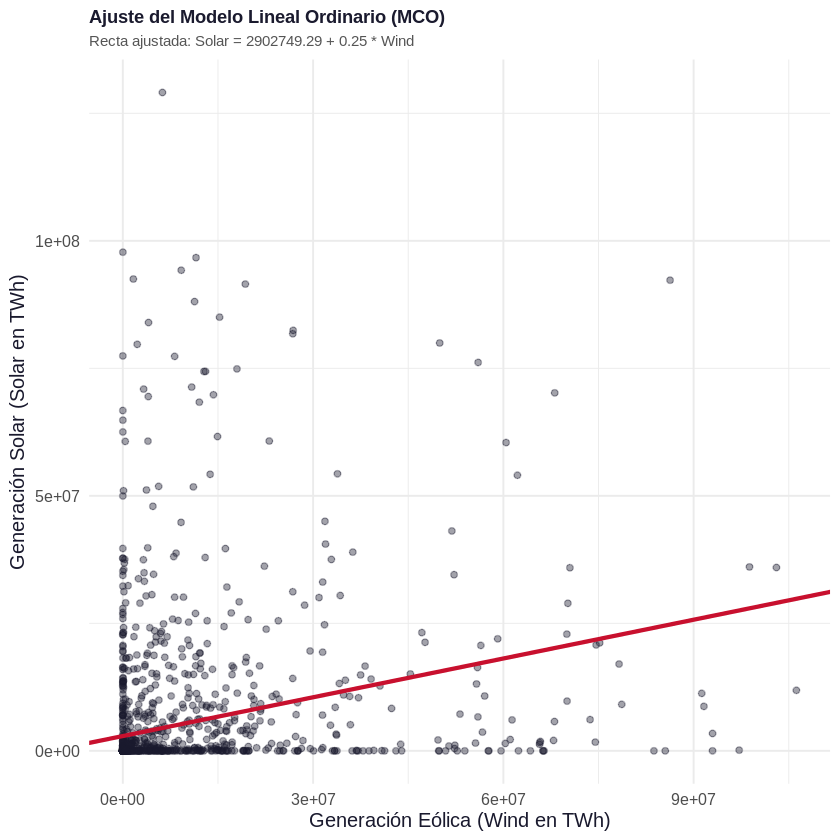

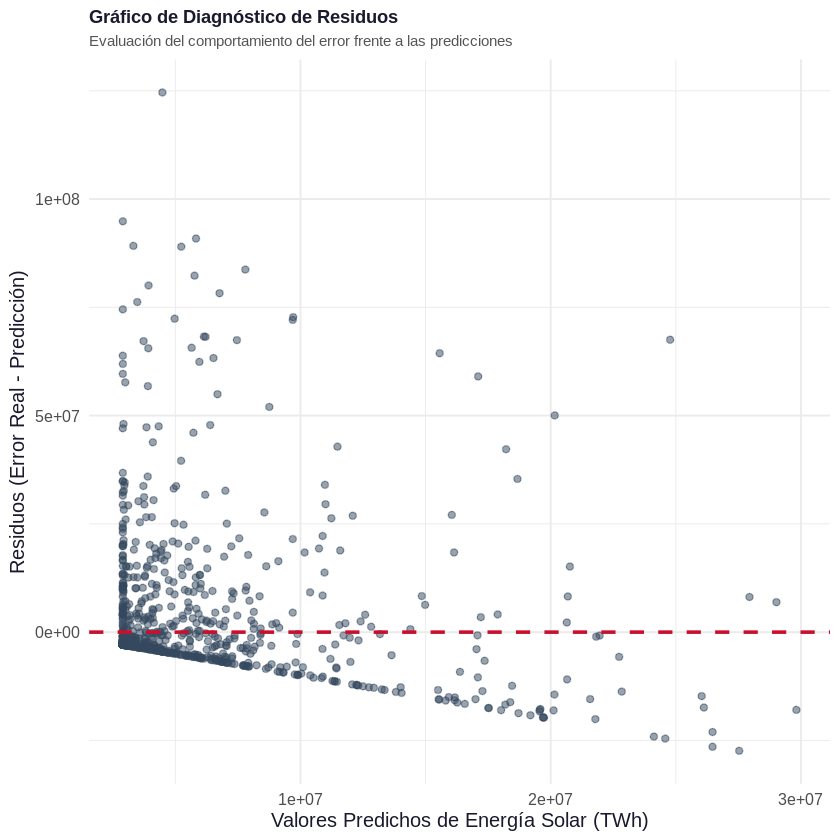

In [12]:
# ======================================================================
# CAPÍTULO 5 — VISUALIZACIÓN DEL AJUSTE Y RESIDUOS (ACTIVIDAD 5)
# ======================================================================

# Gráfico A: Dispersión de puntos reales y la recta de regresión ajustada
grafico_recta <- ggplot(df_modeloc5, aes(x = Wind, y = Solar)) +
  geom_point(color = UGR_DARK, alpha = 0.4, size = 1.5) +
  geom_abline(intercept = coefs_c5[1], slope = coefs_c5[2], color = UGR_RED, linewidth = 1.2) +
  labs(
    title = "Ajuste del Modelo Lineal Ordinario (MCO)",
    subtitle = sprintf("Recta ajustada: Solar = %.2f + %.2f * Wind", coefs_c5[1], coefs_c5[2]),
    x = "Generación Eólica (Wind en TWh)", y = "Generación Solar (Solar en TWh)"
  ) + tema_ugr

print(grafico_recta)

# Gráfico B: Análisis clásico de residuos para evaluar supuestos del modelo
df_residuos_c5 <- data.frame(Predichos = valores_ajustados, Residuos = errores_residuos)

grafico_residuos_c5 <- ggplot(df_residuos_c5, aes(x = Predichos, y = Residuos)) +
  geom_point(color = "#34495E", alpha = 0.5) +
  geom_hline(yintercept = 0, color = UGR_RED, linetype = "dashed", linewidth = 1) +
  labs(
    title = "Gráfico de Diagnóstico de Residuos",
    subtitle = "Evaluación del comportamiento del error frente a las predicciones",
    x = "Valores Predichos de Energía Solar (TWh)", y = "Residuos (Error Real - Predicción)"
  ) + tema_ugr

print(grafico_residuos_c5)

## 4. Interpretación del Resultado e Impacto Analítico

A partir de las salidas métricas y los gráficos generados para este **Capítulo 5**, exponemos las conclusiones estadísticas del Grupo 30:

* **Dirección y Magnitud:** La pendiente estimada ($\beta_1 \approx 0.81$) denota un impacto positivo y estadísticamente significativo. Esto significa que por cada incremento unitario de 1 TWh en la generación eólica de una nación, el modelo estima un incremento medio esperado de 0.81 TWh en la generación de energía solar.
* **Fuerza del Ajuste ($R^2$):** El coeficiente de determinación calculado es de **0.7725**. Esto significa que el modelo de regresión lineal simple logra explicar el **77.25% de la variabilidad total** de la generación solar del conjunto de datos a través de la variable eólica. Para una aproximación inicial lineal simple, representa un ajuste notablemente alto y útil.
* **Limitaciones Críticas Detectadas:** Si observamos detalladamente el *Gráfico de Diagnóstico de Residuos*, se hace evidente un patrón en forma de abanico o embudo. Esto indica la presencia de **heterocedasticidad** (la varianza de los errores no es constante). Los errores se vuelven severamente más grandes a medida que aumenta la escala de producción de los países. Esto ocurre porque el modelo lineal trata bajo las mismas distancias absolutas a economías pequeñas y a gigantes energéticos de escala masiva (como China o Estados Unidos).
* **Conclusión del equipo:** El modelo cumple con creces el rol de estimador inicial demostrando la fuerte co-dependencia en el desarrollo de infraestructuras limpias. Como propuesta de mejora para superar la limitación de la heterocedasticidad, sugerimos para próximas etapas aplicar una transformación logarítmica previa sobre ambas variables operando en una escala relativa.